# Few-Shot Adaptation Benchmark on DermaMNIST

**Why this notebook exists.** On CIFAR-10, zero-shot CLIP already reaches ~90.4% accuracy, which leaves very little headroom for any adaptation method to demonstrate a clear advantage — five different methods (Tip-Adapter, CLIP-LoRA, MaPLe, 2SFS, DINOv2) all converged into the same low-90s band by K=50–100, and the low-K differences that *did* show up were partly obscured by CIFAR-10's ceiling effect. Dermatoscopic skin-lesion images are out-of-distribution for CLIP's entire pretraining corpus in a different way than EuroSAT or Aircraft: this isn't just a weaker zero-shot baseline, it's a domain CLIP's internet-photo pretraining essentially never saw, so zero-shot accuracy could plausibly sit close to random-chance (1/7 ≈ 14.3%) rather than just "weak but informative" the way Aircraft's ~20-30% is. That makes this a different question from the other two datasets: not "does adaptation help when zero-shot is mediocre" but "can these methods bootstrap task-relevant structure when the frozen backbone starts with essentially no usable prior." Treat the two questions separately when writing this up rather than plotting all three datasets on one curve as if they measured the same thing. This also directly feeds the thesis's existing future-work item on few-shot medical image segmentation.

This notebook re-runs the **same five methods, same code, same K-shot protocol** used in the CIFAR-10 notebooks, on **DermaMNIST** (dermatoscopic skin-lesion classification, out-of-distribution for CLIP's pretraining corpus, used here in place of ISIC (which requires manual registration) since DermaMNIST is itself derived from the same HAM10000/ISIC archive), where zero-shot CLIP is expected to be substantially weaker. That gap is exactly the room adaptation methods need to differentiate themselves.

**Methods benchmarked (identical implementations to the CIFAR-10 notebooks):**
1. Zero-shot CLIP baseline
2. Tip-Adapter / Tip-Adapter-F (Zhang et al., ECCV 2022) — training-free cache + optional key fine-tuning
3. CLIP-LoRA (Zanella & Ben Ayed, CVPRW 2024) — rank-4 LoRA on QKV/output projections, both encoders
4. MaPLe, simplified single-layer version (Khattak et al., CVPR 2023) — CoOp-style text context + one text→vision coupling function
5. 2SFS (Farina et al., 2024) — LayerNorm-only Stage 1 + linear-probe Stage 2
6. DINOv2 (Oquab et al., TMLR 2024) — vision-only nearest-prototype / k-NN / linear probe (no zero-shot possible)

**Dataset:** DermaMNIST (7 diagnostic classes: actinic keratoses, basal cell carcinoma, benign keratosis-like lesions, dermatofibroma, melanoma, melanocytic nevi, vascular lesions). Loaded via the `medmnist` package at 64x64 resolution, upscaled by CLIP's own preprocessing to 224x224 like every other dataset here.

**Class count:** 7 classes → shot values swept: [1, 5, 10, 50] (K=100 dropped since several classes -- dermatofibroma, vascular lesions -- have too few images available in DermaMNIST to reliably support K=100; watch for the per-class pool-size warning printed by the loader cell)


---

## 1 — Install packages and load CLIP

In [15]:
# ── Install required packages ──────────────────────────────────────────────
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q medmnist
print("✅ Installed.")

  Preparing metadata (setup.py) ... done
✅ Installed.


In [16]:
# ── Core imports ───────────────────────────────────────────────────────────
import math
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
import numpy as np
import matplotlib.pyplot as plt

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset



import warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU")

Running on: CUDA
GPU: Tesla T4


In [17]:
print("Loading CLIP model (ViT-B/32)...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model = clip_model.float()
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

D_TEXT = clip_model.token_embedding.embedding_dim
D_VISION = clip_model.visual.conv1.out_channels
print(f"✅ CLIP loaded! d_text={{D_TEXT}}, d_vision={{D_VISION}}")

Loading CLIP model (ViT-B/32)...
✅ CLIP loaded! d_text={D_TEXT}, d_vision={D_VISION}


## 2 — Load DermaMNIST and build the K-shot / test splits

In [18]:
import random
print("Downloading DermaMNIST (dermatoscopic skin-lesion images, 7 diagnostic classes)...")
print("Note: used here as an accessible proxy for ISIC, which requires manual registration to download.")
print("DermaMNIST is itself derived from the HAM10000 / ISIC archive, so the domain is the same.")

from medmnist import DermaMNIST

derma_train = DermaMNIST(split='train', download=True, size=64)
derma_test = DermaMNIST(split='test', download=True, size=64)

info = derma_train.info
label_dict = info['label']
N_CLASSES = len(label_dict)
CLASS_NAMES = [label_dict[str(i)] for i in range(N_CLASSES)]
print(f"DermaMNIST classes ({N_CLASSES}):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

def _derma_label(lbl):
    return int(np.array(lbl).squeeze())

TEST_PER_CLASS = 50
rng = random.Random(42)
test_by_class = {c: [] for c in range(N_CLASSES)}
for idx in range(len(derma_test)):
    _, lbl = derma_test[idx]
    test_by_class[_derma_label(lbl)].append(idx)

test_idx_flat = []
for c in range(N_CLASSES):
    idxs = test_by_class[c][:]
    rng.shuffle(idxs)
    take = idxs[:TEST_PER_CLASS]
    if len(take) < TEST_PER_CLASS:
        print(f"⚠️  '{CLASS_NAMES[c]}' has only {len(take)} test images available (< {TEST_PER_CLASS}); "
              f"using all of them. DermaMNIST is heavily class-imbalanced -- expect this warning on "
              f"the rarer classes (e.g. dermatofibroma, vascular lesions).")
    test_idx_flat.extend(take)

print("Materializing the test set into memory (one-time, reused by every method below)...")
all_test_items = []
for i in test_idx_flat:
    img, lbl = derma_test[i]
    all_test_items.append((img.convert('RGB'), _derma_label(lbl)))

TRAIN_POOL_BY_CLASS = {c: [] for c in range(N_CLASSES)}
for idx in range(len(derma_train)):
    _, lbl = derma_train[idx]
    TRAIN_POOL_BY_CLASS[_derma_label(lbl)].append(idx)

def TRAIN_ITEM_FN(idx):
    img, lbl = derma_train[idx]
    return img.convert('RGB'), _derma_label(lbl)

print(f"✅ DermaMNIST ready: {len(all_test_items)} test images, "
      f"train pool sizes/class: {[len(TRAIN_POOL_BY_CLASS[c]) for c in range(N_CLASSES)]}")

Note: used here as an accessible proxy for ISIC, which requires manual registration to download.
DermaMNIST is itself derived from the HAM10000 / ISIC archive, so the domain is the same.
DermaMNIST classes (7):
  0: actinic keratoses and intraepithelial carcinoma
  1: basal cell carcinoma
  2: benign keratosis-like lesions
  3: dermatofibroma
  4: melanoma
  5: melanocytic nevi
  6: vascular lesions
⚠️  'dermatofibroma' has only 23 test images available (< 50); using all of them. DermaMNIST is heavily class-imbalanced -- expect this warning on the rarer classes (e.g. dermatofibroma, vascular lesions).
⚠️  'vascular lesions' has only 29 test images available (< 50); using all of them. DermaMNIST is heavily class-imbalanced -- expect this warning on the rarer classes (e.g. dermatofibroma, vascular lesions).
Materializing the test set into memory (one-time, reused by every method below)...
✅ DermaMNIST ready: 302 test images, train pool sizes/class: [228, 359, 769, 80, 779, 4693, 99]


In [19]:
import random

def build_shot_pairs(k, return_indices=False, seed=0):
    """Samples up to k images per class from the lazy training pool.
    If a class has fewer than k images available, takes all of them (and
    prints nothing here -- see the loader cell's per-class pool-size printout)."""
    rng = random.Random(seed)
    chosen_idx = []
    for c in range(N_CLASSES):
        pool = TRAIN_POOL_BY_CLASS.get(c, [])
        if len(pool) == 0:
            continue
        take = pool if len(pool) <= k else rng.sample(pool, k)
        chosen_idx.extend(take)
    if return_indices:
        return chosen_idx, TRAIN_ITEM_FN
    return [TRAIN_ITEM_FN(i) for i in chosen_idx]

def build_shot_batch(k, seed=0):
    """Same as build_shot_pairs but returns a preprocessed, stacked, device tensor
    pair -- needed by the gradient-based methods (CLIP-LoRA, MaPLe)."""
    pairs = build_shot_pairs(k, seed=seed)
    imgs = torch.stack([clip_preprocess(img.convert('RGB') if hasattr(img, 'convert') else img) for img, _ in pairs]).to(DEVICE)
    labels = torch.tensor([lbl for _, lbl in pairs]).to(DEVICE)
    return imgs, labels

test_pairs = all_test_items
test_index_list = list(range(len(test_pairs)))
test_item_fn = lambda i: test_pairs[i]
test_labels_tensor = torch.tensor([lbl for _, lbl in test_pairs])
test_imgs_batch = torch.stack([clip_preprocess(img.convert('RGB') if hasattr(img, 'convert') else img) for img, _ in test_pairs]).to(DEVICE)
test_labels_batch = test_labels_tensor.to(DEVICE)

pool_sizes = [len(TRAIN_POOL_BY_CLASS.get(c, [])) for c in range(N_CLASSES)]
print(f"Test set: {len(test_pairs)} images across {N_CLASSES} classes")
if N_CLASSES <= 12:
    print("Train shot-pool sizes per class:", {CLASS_NAMES[c]: pool_sizes[c] for c in range(N_CLASSES)})
else:
    print(f"Train shot-pool sizes per class: min={min(pool_sizes)}, max={max(pool_sizes)}, "
          f"median={sorted(pool_sizes)[len(pool_sizes)//2]} (over {N_CLASSES} classes)")

Test set: 302 images across 7 classes
Train shot-pool sizes per class: {'actinic keratoses and intraepithelial carcinoma': 228, 'basal cell carcinoma': 359, 'benign keratosis-like lesions': 769, 'dermatofibroma': 80, 'melanoma': 779, 'melanocytic nevi': 4693, 'vascular lesions': 99}


## 3 — Zero-shot CLIP baseline

Prompt template: `"a dermatoscopic image of {}"` -- a clinical framing matched to how DermaMNIST/ISIC images are actually captured (dermatoscopy), rather than a generic "a photo of a {}" template.

In [20]:
text_prompts = ["a dermatoscopic image of {}".format(c) for c in CLASS_NAMES]
text_tokens = clip.tokenize(text_prompts, truncate=True).to(DEVICE)

with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
print(f"Text classifier shape: {{text_features.shape}}")

with torch.no_grad():
    zs_img_feats = clip_model.encode_image(test_imgs_batch)
    zs_img_feats = zs_img_feats / zs_img_feats.norm(dim=-1, keepdim=True)
    zs_logits = 100.0 * zs_img_feats @ text_features.T
    zeroshot_acc = (zs_logits.argmax(dim=1) == test_labels_batch).float().mean().item() * 100

print(f"Zero-shot CLIP accuracy on this test set: {{zeroshot_acc:.1f}}%")
print(f"(For reference: CIFAR-10 zero-shot CLIP was ~90.4-90.6% on the same backbone -- "
      f"a lower number here means more headroom for adaptation methods to show a difference.)")

Text classifier shape: {text_features.shape}
Zero-shot CLIP accuracy on this test set: {zeroshot_acc:.1f}%
(For reference: CIFAR-10 zero-shot CLIP was ~90.4-90.6% on the same backbone -- a lower number here means more headroom for adaptation methods to show a difference.)


---

## 4 — Tip-Adapter and Tip-Adapter-F

Non-parametric key-value cache built from L2-normalized CLIP image features of the K-shot support set. `(β, α)` are chosen per-K by a small grid search on the support set itself, exactly as in the CIFAR-10 notebook.

In [21]:
# ── Tip-Adapter core ──────────────────────────────────────────────────────
N_CLASSES = 7

def extract_clip_features(dataset_or_pairs):
    """Accepts an iterable of (PIL_image_or_tensor, label)."""
    feats, labels = [], []
    clip_model.eval()
    with torch.no_grad():
        for img, label in dataset_or_pairs:
            pil_img = img if hasattr(img, 'convert') else transforms.ToPILImage()(img)
            inp = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)
            feat = clip_model.encode_image(inp)
            feat = feat / feat.norm(dim=-1, keepdim=True)
            feats.append(feat.cpu())
            labels.append(label)
    return torch.cat(feats, dim=0).float(), torch.tensor(labels)

print("Extracting CLIP test features (cached, reused across all K)...")
F_test, y_test = extract_clip_features(test_pairs)
print(f"F_test shape: {F_test.shape}")

clip_logits_zs = 100.0 * (F_test.to(DEVICE) @ text_features.T)
zs_preds = clip_logits_zs.argmax(dim=1).cpu()
zeroshot_acc = (zs_preds == y_test).float().mean().item() * 100
print(f"Zero-shot CLIP accuracy on this test set: {zeroshot_acc:.1f}%")

def build_cache(k):
    shot_pairs = build_shot_pairs(k)
    F_train, y_train = extract_clip_features(shot_pairs)
    L_train = torch.nn.functional.one_hot(y_train, num_classes=N_CLASSES).float()
    return F_train, L_train, y_train

def tip_adapter_logits(F_train, L_train, F_query, beta, alpha, clip_logits):
    affinity = ((-1) * beta * (1 - F_query.to(DEVICE) @ F_train.to(DEVICE).T)).exp()
    cache_logits = affinity @ L_train.to(DEVICE)
    return alpha * cache_logits + clip_logits

def search_hyperparams(F_train, L_train, y_train, clip_logits_train,
                        beta_list=(1, 2, 3, 5, 8, 11, 15, 20),
                        alpha_list=(0.5, 1, 2, 3, 5, 8, 12, 20)):
    best_acc, best_beta, best_alpha = -1, beta_list[0], alpha_list[0]
    for beta in beta_list:
        for alpha in alpha_list:
            logits = tip_adapter_logits(F_train, L_train, F_train, beta, alpha, clip_logits_train)
            preds = logits.argmax(dim=1).cpu()
            acc = (preds == y_train).float().mean().item() * 100
            if acc > best_acc:
                best_acc, best_beta, best_alpha = acc, beta, alpha
    return best_beta, best_alpha

def tip_adapter_finetune(F_train, L_train, y_train, clip_logits_train,
                          beta, alpha, epochs=20, lr=1e-3):
    adapter_keys = F_train.clone().to(DEVICE).requires_grad_(True)
    optimizer = torch.optim.AdamW([adapter_keys], lr=lr, eps=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    y_train_dev = y_train.to(DEVICE)
    for epoch in range(epochs):
        affinity = ((-1) * beta * (1 - F_train.to(DEVICE) @ adapter_keys.T)).exp()
        cache_logits = affinity @ L_train.to(DEVICE)
        logits = alpha * cache_logits + clip_logits_train
        loss = criterion(logits, y_train_dev)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return adapter_keys.detach().cpu()

K_VALUES = [1, 5, 10, 50]
tip_results = {'zeroshot': zeroshot_acc, 'tip_adapter': {}, 'tip_adapter_f': {}, 'hparams': {}}

print(f"{'K':>5} {'Zero-shot':>10} {'Tip-Adapter':>13} {'Tip-Adapter-F':>15}   (beta, alpha)")
print("-" * 68)

for k in K_VALUES:
    F_train, L_train, y_train = build_cache(k)
    clip_logits_train = 100.0 * (F_train.to(DEVICE) @ text_features.T)
    beta, alpha = search_hyperparams(F_train, L_train, y_train, clip_logits_train)
    tip_results['hparams'][k] = (beta, alpha)

    logits_ta = tip_adapter_logits(F_train, L_train, F_test, beta, alpha, clip_logits_zs)
    preds_ta = logits_ta.argmax(dim=1).cpu()
    acc_ta = (preds_ta == y_test).float().mean().item() * 100
    tip_results['tip_adapter'][k] = acc_ta

    epochs = 20 if k <= 20 else 10
    tuned_keys = tip_adapter_finetune(F_train, L_train, y_train, clip_logits_train, beta, alpha, epochs=epochs)
    logits_taf = tip_adapter_logits(tuned_keys, L_train, F_test, beta, alpha, clip_logits_zs)
    preds_taf = logits_taf.argmax(dim=1).cpu()
    acc_taf = (preds_taf == y_test).float().mean().item() * 100
    tip_results['tip_adapter_f'][k] = acc_taf

    print(f"{k:>5} {zeroshot_acc:>9.1f}% {acc_ta:>12.1f}% {acc_taf:>14.1f}%   (β={beta}, α={alpha})")

print("-" * 68)

Extracting CLIP test features (cached, reused across all K)...
F_test shape: torch.Size([302, 512])
Zero-shot CLIP accuracy on this test set: 23.2%
    K  Zero-shot   Tip-Adapter   Tip-Adapter-F   (beta, alpha)
--------------------------------------------------------------------
    1      23.2%         24.5%           26.2%   (β=1, α=20)
    5      23.2%         38.1%           33.1%   (β=20, α=5)
   10      23.2%         38.4%           37.7%   (β=20, α=12)
   50      23.2%         49.3%           49.3%   (β=20, α=5)
--------------------------------------------------------------------


---

## 5 — CLIP-LoRA

Rank-4 LoRA adapters injected into the fused QKV and output projections of both the visual and text transformers' attention blocks. Original CLIP weights stay frozen; only `lora_*` parameters train.

In [22]:
class LoRAMultiheadAttention(nn.Module):
    """Drop-in replacement for nn.MultiheadAttention that adds a trainable
    low-rank delta to the QKV and output projections (Hu et al., 2021 LoRA,
    as applied to CLIP by Zanella & Ben Ayed, 2024). Original weights frozen."""

    def __init__(self, orig_attn, rank=4, alpha=1.0):
        super().__init__()
        self.embed_dim = orig_attn.embed_dim
        self.num_heads = orig_attn.num_heads
        self.rank = rank
        self.scaling = alpha / rank
        d = self.embed_dim

        self.in_proj_weight = nn.Parameter(orig_attn.in_proj_weight.data.clone(), requires_grad=False)
        self.in_proj_bias = nn.Parameter(orig_attn.in_proj_bias.data.clone(), requires_grad=False) \
            if orig_attn.in_proj_bias is not None else None
        self.out_proj_weight = nn.Parameter(orig_attn.out_proj.weight.data.clone(), requires_grad=False)
        self.out_proj_bias = nn.Parameter(orig_attn.out_proj.bias.data.clone(), requires_grad=False) \
            if orig_attn.out_proj.bias is not None else None

        self.lora_in_A = nn.Parameter(torch.zeros(rank, d))
        self.lora_in_B = nn.Parameter(torch.zeros(3 * d, rank))
        nn.init.kaiming_uniform_(self.lora_in_A, a=math.sqrt(5))

        self.lora_out_A = nn.Parameter(torch.zeros(rank, d))
        self.lora_out_B = nn.Parameter(torch.zeros(d, rank))
        nn.init.kaiming_uniform_(self.lora_out_A, a=math.sqrt(5))

    def forward(self, query, key, value, need_weights=False, attn_mask=None):
        merged_in_weight  = self.in_proj_weight  + (self.lora_in_B  @ self.lora_in_A)  * self.scaling
        merged_out_weight = self.out_proj_weight + (self.lora_out_B @ self.lora_out_A) * self.scaling
        attn_output, attn_weights = F.multi_head_attention_forward(
            query, key, value,
            self.embed_dim, self.num_heads,
            merged_in_weight, self.in_proj_bias,
            None, None, False,
            0.0,
            merged_out_weight, self.out_proj_bias,
            training=self.training,
            need_weights=need_weights,
            attn_mask=attn_mask,
        )
        return attn_output, attn_weights

def inject_lora(clip_model_, rank=4, alpha=1.0):
    lora_params = []
    for blk in list(clip_model_.visual.transformer.resblocks) + list(clip_model_.transformer.resblocks):
        blk.attn = LoRAMultiheadAttention(blk.attn, rank=rank, alpha=alpha).to(DEVICE)
        lora_params += [blk.attn.lora_in_A, blk.attn.lora_in_B, blk.attn.lora_out_A, blk.attn.lora_out_B]
    return lora_params

In [23]:
def train_clip_lora(k, rank=4, alpha=1.0, epochs=15, lr=2e-4, batch_size=32):
    model = copy.deepcopy(clip_model)
    for p in model.parameters():
        p.requires_grad = False
    lora_params = inject_lora(model, rank=rank, alpha=alpha)
    optimizer = torch.optim.AdamW(lora_params, lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_imgs, train_labels = build_shot_batch(k)
    n_samples = train_imgs.shape[0]
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n_samples)
        for start in range(0, n_samples, batch_size):
            batch_idx = perm[start:start + batch_size]
            bx, by = train_imgs[batch_idx], train_labels[batch_idx]
            img_feats = model.encode_image(bx)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
            txt_feats = model.encode_text(text_tokens)
            txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
            logits = 100.0 * img_feats @ txt_feats.T
            loss = criterion(logits, by)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    n_trainable = sum(p.numel() for p in lora_params)
    return model, n_trainable

def eval_clip_lora(model, test_imgs, test_labels):
    model.eval()
    with torch.no_grad():
        img_feats = model.encode_image(test_imgs)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        txt_feats = model.encode_text(text_tokens)
        txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
        logits = 100.0 * img_feats @ txt_feats.T
        preds = logits.argmax(dim=1)
    return (preds == test_labels).float().mean().item() * 100

lora_results = {'accuracy': {}, 'n_trainable': {}}
print(f"{'K':>5} {'Zero-shot':>10} {'CLIP-LoRA':>11}")
print("-" * 30)

for k in K_VALUES:
    epochs = 15 if k <= 20 else 8
    lora_model, n_trainable = train_clip_lora(k, epochs=epochs)
    acc = eval_clip_lora(lora_model, test_imgs_batch, test_labels_batch)
    lora_results['accuracy'][k] = acc
    lora_results['n_trainable'][k] = n_trainable
    print(f"{k:>5} {zeroshot_acc:>9.1f}% {acc:>10.1f}%")

print("-" * 30)
print(f"\nTrainable LoRA parameters: {lora_results['n_trainable'][K_VALUES[0]]:,}")

    K  Zero-shot   CLIP-LoRA
------------------------------
    1      23.2%       27.8%
    5      23.2%       31.1%
   10      23.2%       36.1%
   50      23.2%       54.3%
------------------------------

Trainable LoRA parameters: 368,640


---

## 6 — MaPLe (simplified, single-layer)

Same simplification as the CIFAR-10 notebook: CoOp-style learnable text context (`N_ctx=4`) plus a single linear coupling function projecting that context into vision-branch prompt tokens, injected once at the input of the ViT — not the full 9-layer deep-prompting architecture from the paper.

In [24]:
N_CTX = 4

class MaPLePrompts(nn.Module):
    def __init__(self, classnames, n_ctx=N_CTX, d_text=D_TEXT, d_vision=D_VISION):
        super().__init__()
        self.n_ctx = n_ctx
        self.n_cls = len(classnames)
        self.ctx = nn.Parameter(torch.randn(n_ctx, d_text) * 0.02)
        self.coupling_fn = nn.Linear(d_text, d_vision)

        prompt_prefix = " ".join(["X"] * n_ctx)
        prompts = [f"{prompt_prefix} {name}." for name in classnames]
        tokenized = clip.tokenize(prompts, truncate=True).to(DEVICE)
        self.register_buffer("tokenized_prompts", tokenized)

        with torch.no_grad():
            embedding = clip_model.token_embedding(tokenized).type(clip_model.dtype)
        self.register_buffer("token_prefix", embedding[:, :1, :])
        self.register_buffer("token_suffix", embedding[:, 1 + n_ctx:, :])

    def build_text_embeddings(self):
        ctx_expanded = self.ctx.unsqueeze(0).expand(self.n_cls, -1, -1)
        return torch.cat([self.token_prefix, ctx_expanded, self.token_suffix], dim=1)

    def build_vision_prompts(self):
        return self.coupling_fn(self.ctx)

prompt_module = MaPLePrompts(CLASS_NAMES).to(DEVICE)
print(f"Trainable parameters: ctx={prompt_module.ctx.numel()}, "
      f"coupling_fn={sum(p.numel() for p in prompt_module.coupling_fn.parameters())}")

Trainable parameters: ctx=2048, coupling_fn=393984


In [25]:
def encode_text_with_prompts(prompt_module):
    x = prompt_module.build_text_embeddings()
    x = x + clip_model.positional_embedding.type(clip_model.dtype)
    x = x.permute(1, 0, 2)
    x = clip_model.transformer(x)
    x = x.permute(1, 0, 2)
    x = clip_model.ln_final(x).type(clip_model.dtype)
    eot_idx = prompt_module.tokenized_prompts.argmax(dim=-1)
    x = x[torch.arange(x.shape[0]), eot_idx] @ clip_model.text_projection
    return x

def encode_image_with_prompts(images, prompt_module):
    visual = clip_model.visual
    x = visual.conv1(images.type(clip_model.dtype))
    x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
    cls_tok = visual.class_embedding.to(x.dtype) + torch.zeros(x.shape[0], 1, x.shape[-1], device=x.device, dtype=x.dtype)
    x = torch.cat([cls_tok, x], dim=1)
    x = x + visual.positional_embedding.to(x.dtype)
    vision_prompts = prompt_module.build_vision_prompts().unsqueeze(0).expand(x.shape[0], -1, -1)
    x = torch.cat([x[:, :1, :], vision_prompts.type(x.dtype), x[:, 1:, :]], dim=1)
    x = visual.ln_pre(x)
    x = x.permute(1, 0, 2)
    x = visual.transformer(x)
    x = x.permute(1, 0, 2)
    x = visual.ln_post(x[:, 0, :])
    if visual.proj is not None:
        x = x @ visual.proj
    return x

In [14]:
def train_maple(k, epochs=25, lr=2e-3, batch_size=32):
    prompts = MaPLePrompts(CLASS_NAMES).to(DEVICE)
    optimizer = torch.optim.AdamW(list(prompts.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_imgs, train_labels = build_shot_batch(k)
    n_samples = train_imgs.shape[0]
    for epoch in range(epochs):
        perm = torch.randperm(n_samples)
        for start in range(0, n_samples, batch_size):
            batch_idx = perm[start:start + batch_size]
            bx, by = train_imgs[batch_idx], train_labels[batch_idx]
            img_feats = encode_image_with_prompts(bx, prompts)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
            txt_feats = encode_text_with_prompts(prompts)
            txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
            logits = 100.0 * img_feats @ txt_feats.T
            loss = criterion(logits, by)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    n_trainable = sum(p.numel() for p in prompts.parameters())
    return prompts, n_trainable

def eval_maple(prompts, test_imgs, test_labels):
    with torch.no_grad():
        img_feats = encode_image_with_prompts(test_imgs, prompts)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        txt_feats = encode_text_with_prompts(prompts)
        txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
        logits = 100.0 * img_feats @ txt_feats.T
        preds = logits.argmax(dim=1)
    return (preds == test_labels).float().mean().item() * 100

maple_results = {'accuracy': {}, 'n_trainable': {}}
print(f"{'K':>5} {'Zero-shot':>10} {'MaPLe (simplified)':>20}")
print("-" * 38)

for k in K_VALUES:
    epochs = 25 if k <= 20 else 12
    prompts, n_trainable = train_maple(k, epochs=epochs)
    acc = eval_maple(prompts, test_imgs_batch, test_labels_batch)
    maple_results['accuracy'][k] = acc
    maple_results['n_trainable'][k] = n_trainable
    print(f"{k:>5} {zeroshot_acc:>9.1f}% {acc:>19.1f}%")

print("-" * 38)
print(f"\nTrainable parameters (ctx + coupling_fn): {maple_results['n_trainable'][K_VALUES[0]]:,}")

    K  Zero-shot   MaPLe (simplified)
--------------------------------------
    1      23.2%                34.8%
    5      23.2%                30.1%
   10      23.2%                30.1%
   50      23.2%                57.9%
--------------------------------------

Trainable parameters (ctx + coupling_fn): 396,032


---

## 7 — 2SFS (Two-Stage Few-Shot)

Stage 1 fine-tunes only the LayerNorm affine parameters of CLIP's visual encoder, using a held-out validation split (where K permits) to detect the breakpoint epoch. Stage 2 freezes the adapted encoder and trains a linear probe on top.

In [28]:
def get_layernorm_param_names(model):
    names = []
    for name, module in model.visual.named_modules():
        if isinstance(module, nn.LayerNorm):
            names.append(name)
    return names

def batch_from_indices(indices, get_item):
    imgs, labels = [], []
    for i in indices:
        pil_img, lbl = get_item(i)
        pil_img = pil_img.convert('RGB') if hasattr(pil_img, 'convert') else pil_img
        imgs.append(clip_preprocess(pil_img))
        labels.append(lbl)
    imgs = torch.stack(imgs).to(DEVICE)
    labels = torch.tensor(labels).to(DEVICE)
    return imgs, labels

def freeze_all_except_layernorm(model):
    trainable_params = []
    ln_names = set(get_layernorm_param_names(model))
    for name, param in model.visual.named_parameters():
        parent = name.rsplit('.', 1)[0]
        if parent in ln_names:
            param.requires_grad = True
            trainable_params.append(param)
        else:
            param.requires_grad = False
    for param in model.transformer.parameters():
        param.requires_grad = False
    return trainable_params

n_ln_layers = len(get_layernorm_param_names(clip_model))
print(f"Found {n_ln_layers} LayerNorm modules in the visual encoder.")

class LinearProbe2SFS(nn.Module):
    def __init__(self, input_dim=512, num_classes=7):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.fc(x)

def stage1_finetune(k, epochs=15, lr=1e-4):
    all_pairs = build_shot_pairs(k, return_indices=True)
    all_idx, get_item = all_pairs

    if k >= 2:
        val_frac = max(1, k // 5)
        by_class = {}
        for i in all_idx:
            lbl = get_item(i)[1]
            by_class.setdefault(lbl, []).append(i)
        val_idx, train_idx = [], []
        for c, idxs in by_class.items():
            val_idx.extend(idxs[:val_frac])
            train_idx.extend(idxs[val_frac:])
    else:
        train_idx, val_idx = all_idx, all_idx

    model = copy.deepcopy(clip_model)
    trainable_params = freeze_all_except_layernorm(model)
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_imgs, train_labels = batch_from_indices(train_idx, get_item)
    val_imgs, val_labels = batch_from_indices(val_idx, get_item)

    best_val_acc, best_state, breakpoint_epoch = -1, None, 0
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        feats = model.encode_image(train_imgs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = 100.0 * feats @ text_features.T
        loss = criterion(logits, train_labels)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_feats = model.encode_image(val_imgs)
            val_feats = val_feats / val_feats.norm(dim=-1, keepdim=True)
            val_logits = 100.0 * val_feats @ text_features.T
            val_acc = (val_logits.argmax(dim=1) == val_labels).float().mean().item() * 100

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            breakpoint_epoch = epoch + 1
            best_state = copy.deepcopy({n: p.detach().clone() for n, p in model.visual.named_parameters() if p.requires_grad})

    with torch.no_grad():
        for n, p in model.visual.named_parameters():
            if n in best_state:
                p.copy_(best_state[n])

    return model, breakpoint_epoch, best_val_acc, all_idx, get_item

def stage2_linear_probe(model, train_idx, get_item, epochs=10, lr=1e-3, batch_size=64):
    def extract(indices, item_fn):
        feats = []
        model.eval()
        with torch.no_grad():
            for i in indices:
                pil_img, _ = item_fn(i)
                inp = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)
                f = model.encode_image(inp)
                f = f / f.norm(dim=-1, keepdim=True)
                feats.append(f.cpu())
        return torch.cat(feats, dim=0).float()

    X_train = extract(train_idx, get_item)
    y_train = torch.tensor([get_item(i)[1] for i in train_idx])
    X_test, y_test_local = test_feats_2sfs, test_labels_2sfs

    probe = LinearProbe2SFS(X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train.to(DEVICE), y_train.to(DEVICE)),
        batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        probe.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(probe(bx), by)
            loss.backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        preds = probe(X_test.to(DEVICE)).argmax(dim=1).cpu()
    return (preds == y_test_local).float().mean().item() * 100

# Extract fixed test features once for Stage 2 evaluation (2SFS uses the *adapted* encoder,
# so we still must re-extract per-model, but the labels/order are fixed for all K).
def extract_with_model(model, item_fn, indices):
    feats = []
    model.eval()
    with torch.no_grad():
        for i in indices:
            pil_img, _ = item_fn(i)
            inp = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)
            f = model.encode_image(inp)
            f = f / f.norm(dim=-1, keepdim=True)
            feats.append(f.cpu())
    return torch.cat(feats, dim=0).float()

twosfs_results = {'breakpoint_epoch': {}, 'stage1_val_acc': {}, 'final_test_acc': {}, 'n_trainable': {}}
print(f"{'K':>5} {'Breakpoint ep.':>15} {'Stage1 val acc':>15} {'Final test acc':>16}")
print("-" * 58)

for k in K_VALUES:
    adapted_model, bp_epoch, val_acc, all_idx, get_item = stage1_finetune(k)
    test_feats_2sfs = extract_with_model(adapted_model, test_item_fn, test_index_list)
    test_labels_2sfs = test_labels_tensor
    test_acc = stage2_linear_probe(adapted_model, all_idx, get_item)

    n_trainable = sum(p.numel() for n, p in adapted_model.visual.named_parameters() if p.requires_grad)
    twosfs_results['breakpoint_epoch'][k] = bp_epoch
    twosfs_results['stage1_val_acc'][k] = val_acc
    twosfs_results['final_test_acc'][k] = test_acc
    twosfs_results['n_trainable'][k] = n_trainable

    print(f"{k:>5} {bp_epoch:>15} {val_acc:>14.1f}% {test_acc:>15.1f}%")

print("-" * 58)
print(f"\nTrainable LayerNorm parameters (Stage 1): {twosfs_results['n_trainable'][K_VALUES[0]]:,}")

Found 26 LayerNorm modules in the visual encoder.
    K  Breakpoint ep.  Stage1 val acc   Final test acc
----------------------------------------------------------
    1               1           14.3%            24.5%
    5               8           42.9%            28.1%
   10              10           28.6%            13.2%
   50              14           22.9%            41.7%
----------------------------------------------------------

Trainable LayerNorm parameters (Stage 1): 39,936


---

## 8 — DINOv2 (vision-only comparison)

DINOv2 has no text tower, so no zero-shot number exists for it — every result below needs at least K=1 labeled example. Evaluated under three protocols: nearest-prototype, k-NN, and linear probing on frozen CLS-token features.

In [29]:
from transformers import AutoImageProcessor, AutoModel

MODEL_NAME = "facebook/dinov2-small"
print(f"Loading {MODEL_NAME}...")
dino_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
dino_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
dino_model.eval()
EMBED_DIM = dino_model.config.hidden_size
print(f"✅ DINOv2 loaded! Embedding dim: {EMBED_DIM}")

def extract_dino_features(pairs):
    feats, labels = [], []
    with torch.no_grad():
        for img, label in pairs:
            pil_img = img if hasattr(img, 'convert') else transforms.ToPILImage()(img)
            inputs = dino_processor(images=pil_img, return_tensors="pt").to(DEVICE)
            out = dino_model(**inputs)
            cls_feat = out.last_hidden_state[:, 0, :]
            cls_feat = F.normalize(cls_feat, dim=-1)
            feats.append(cls_feat.cpu())
            labels.append(label)
    return torch.cat(feats, dim=0).float(), torch.tensor(labels)

print("Extracting DINOv2 test features...")
F_test_dino, y_test_dino = extract_dino_features(test_pairs)
print(f"F_test shape: {F_test_dino.shape}")

def eval_prototype(F_train, y_train, F_query, y_query, n_classes=7):
    prototypes = torch.stack([F_train[y_train == c].mean(dim=0) for c in range(n_classes)])
    prototypes = F.normalize(prototypes, dim=-1)
    sims = F_query @ prototypes.T
    preds = sims.argmax(dim=1)
    return (preds == y_query).float().mean().item() * 100

def eval_knn(F_train, y_train, F_query, y_query, k_neighbors=5):
    k_neighbors = min(k_neighbors, F_train.shape[0])
    sims = F_query @ F_train.T
    topk = sims.topk(k_neighbors, dim=1).indices
    topk_labels = y_train[topk]
    preds = torch.mode(topk_labels, dim=1).values
    return (preds == y_query).float().mean().item() * 100

class LinearProbeDino(torch.nn.Module):
    def __init__(self, input_dim, num_classes=7):
        super().__init__()
        self.fc = torch.nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.fc(x)

def eval_linear_probe_dino(F_train, y_train, F_query, y_query, epochs=20, lr=1e-3, batch_size=64):
    probe = LinearProbeDino(F_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(F_train.to(DEVICE), y_train.to(DEVICE)),
        batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        probe.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(probe(bx), by)
            loss.backward()
            optimizer.step()
    probe.eval()
    with torch.no_grad():
        preds = probe(F_query.to(DEVICE)).argmax(dim=1).cpu()
    return (preds == y_query).float().mean().item() * 100

dino_results = {'prototype': {}, 'knn': {}, 'linear_probe': {}}
print(f"{'K':>5} {'Prototype':>11} {'k-NN':>8} {'Linear Probe':>14}")
print("-" * 44)

for k in K_VALUES:
    shot_pairs = build_shot_pairs(k)
    F_train, y_train = extract_dino_features(shot_pairs)

    acc_proto = eval_prototype(F_train, y_train, F_test_dino, y_test_dino)
    acc_knn = eval_knn(F_train, y_train, F_test_dino, y_test_dino, k_neighbors=min(5, k))
    acc_lp = eval_linear_probe_dino(F_train, y_train, F_test_dino, y_test_dino)

    dino_results['prototype'][k] = acc_proto
    dino_results['knn'][k] = acc_knn
    dino_results['linear_probe'][k] = acc_lp

    print(f"{k:>5} {acc_proto:>10.1f}% {acc_knn:>7.1f}% {acc_lp:>13.1f}%")

print("-" * 44)

Loading facebook/dinov2-small...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

✅ DINOv2 loaded! Embedding dim: 384
Extracting DINOv2 test features...
F_test shape: torch.Size([302, 384])
    K   Prototype     k-NN   Linear Probe
--------------------------------------------
    1       21.5%    21.5%          21.5%
    5       39.1%    36.1%          41.1%
   10       43.4%    34.4%          20.9%
   50       50.3%    43.0%          45.0%
--------------------------------------------


---

## 9 — Cross-method summary on DermaMNIST

In [31]:
# ── Cross-method summary table ───────────────────────────────────────────────
print("=" * 78)
print(f"  DERMAMNIST — CROSS-METHOD SUMMARY")
print("=" * 78)
print(f"\nZero-shot CLIP (K=0): {zeroshot_acc:.1f}%\n")

header = f"{'K':>5} {'ZeroShot':>9} {'Tip-Ad':>8} {'Tip-Ad-F':>9} {'CLIP-LoRA':>10} {'MaPLe':>8} {'2SFS':>8} {'DINOv2-proto':>13}"
print(header)
print("-" * len(header))
for k in K_VALUES:
    row = (f"{k:>5} {zeroshot_acc:>8.1f}% {tip_results['tip_adapter'][k]:>7.1f}% "
           f"{tip_results['tip_adapter_f'][k]:>8.1f}% {lora_results['accuracy'][k]:>9.1f}% "
           f"{maple_results['accuracy'][k]:>7.1f}% {twosfs_results['final_test_acc'][k]:>7.1f}% "
           f"{dino_results['prototype'][k]:>12.1f}%")
    print(row)
print("-" * len(header))

  DERMAMNIST — CROSS-METHOD SUMMARY

Zero-shot CLIP (K=0): 23.2%

    K  ZeroShot   Tip-Ad  Tip-Ad-F  CLIP-LoRA    MaPLe     2SFS  DINOv2-proto
-----------------------------------------------------------------------------
    1     23.2%    24.5%     26.2%      27.8%    34.8%    24.5%         21.5%
    5     23.2%    38.1%     33.1%      31.1%    30.1%    28.1%         39.1%
   10     23.2%    38.4%     37.7%      36.1%    30.1%    13.2%         43.4%
   50     23.2%    49.3%     49.3%      54.3%    57.9%    41.7%         50.3%
-----------------------------------------------------------------------------


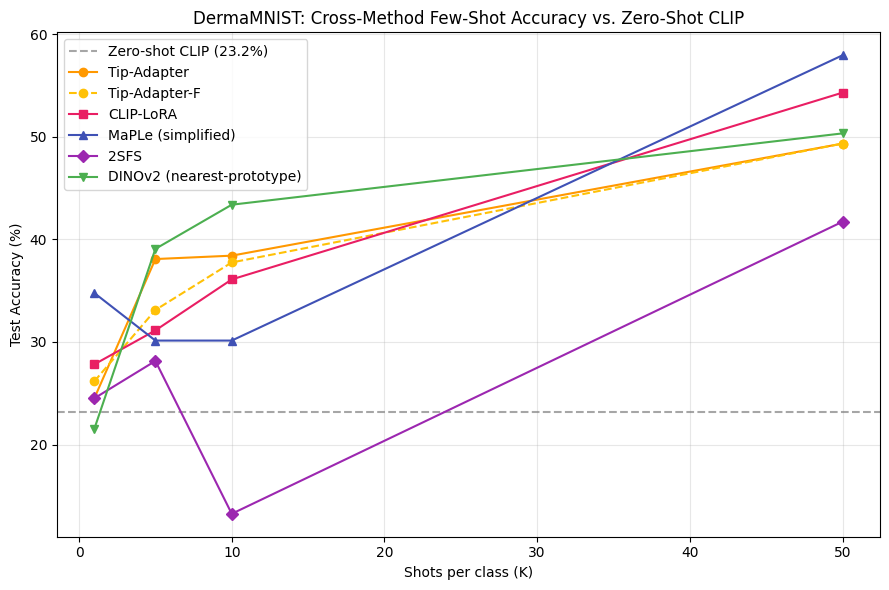

In [32]:
# ── Cross-method comparison plot ─────────────────────────────────────────────
plt.figure(figsize=(9, 6))
plt.axhline(zeroshot_acc, color='gray', linestyle='--', alpha=0.7, label=f'Zero-shot CLIP ({zeroshot_acc:.1f}%)')
plt.plot(K_VALUES, [tip_results['tip_adapter'][k] for k in K_VALUES], 'o-', label='Tip-Adapter', color='#FF9800')
plt.plot(K_VALUES, [tip_results['tip_adapter_f'][k] for k in K_VALUES], 'o--', label='Tip-Adapter-F', color='#FFC107')
plt.plot(K_VALUES, [lora_results['accuracy'][k] for k in K_VALUES], 's-', label='CLIP-LoRA', color='#E91E63')
plt.plot(K_VALUES, [maple_results['accuracy'][k] for k in K_VALUES], '^-', label='MaPLe (simplified)', color='#3F51B5')
plt.plot(K_VALUES, [twosfs_results['final_test_acc'][k] for k in K_VALUES], 'D-', label='2SFS', color='#9C27B0')
plt.plot(K_VALUES, [dino_results['prototype'][k] for k in K_VALUES], 'v-', label='DINOv2 (nearest-prototype)', color='#4CAF50')

plt.xlabel('Shots per class (K)')
plt.ylabel('Test Accuracy (%)')
plt.title(f'DermaMNIST: Cross-Method Few-Shot Accuracy vs. Zero-Shot CLIP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dermamnist_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Notes on fidelity and how to read these results

- All five method implementations are byte-for-byte the same logic as the CIFAR-10 notebooks (`Tip_Adapter_CLIP.ipynb`, `CLIP_LoRA.ipynb`, `MaPLe_Simplified.ipynb`, `TwoStage_2SFS.ipynb`, `DINOv2_FewShot.ipynb`) — only the dataset loader, class list, prompt template, and (where noted) the K-shot values changed. This keeps the comparison to the CIFAR-10 results controlled: any difference in *behavior* (e.g. whether the low-K dip appears, whether methods separate from each other) is attributable to the dataset's zero-shot headroom, not to a different implementation.
- DermaMNIST is heavily class-imbalanced (melanocytic nevi alone account for roughly two-thirds of all images); the `build_shot_pairs` helper falls back to "take all available" when a class has fewer than K images, so the *effective* K for rare classes at K=50 may be smaller than for common ones -- read the loader cell's warnings before interpreting the K=50 row. This class imbalance is itself realistic for medical imaging and directly relevant to the thesis's future-work discussion of few-shot medical segmentation, where rare-condition data scarcity is the whole point.
- As on CIFAR-10, MaPLe here is the single-layer simplification (not the full 9-layer architecture) and 2SFS's breakpoint detection is the simple validation-accuracy-peak heuristic — both carry the same fidelity caveats documented in the CIFAR-10 notebooks and in Chapter 5/6 of the report.
- Compare the resulting K-shot curves directly against the CIFAR-10 versions: if the ceiling-effect hypothesis is right, methods should separate from each other and from zero-shot more clearly here than they did on CIFAR-10, especially at low K.
